# SNN Simulation from Scratch

Spiking Neural Network implementation using discrete-time LIF neurons.

In [31]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import os

network_path = 'results/best.json'

if network_path is None:
    raise FileNotFoundError("best.json not found.")

with open(network_path, 'r') as f:
    network_config = json.load(f)

if 'neurons' in network_config:
    num_neurons = len(network_config['neurons'])
    num_synapses = len(network_config['synapses'])
else:
    num_neurons = len(network_config.get('Nodes', []))
    num_synapses = len(network_config.get('Edges', []))

print(f'Network loaded from: {network_path}')
print(f'Network: {num_neurons} neurons, {num_synapses} synapses')

Network loaded from: results/best.json
Network: 6 neurons, 13 synapses


### LIF Neuron Model from scratch

In [32]:
class LIFNeuron:

    def __init__(self, neuron_id, threshold, leak=0.0):
        self.neuron_id = neuron_id
        self.threshold = threshold
        self.leak = leak
        self.charge = 0
        self.fire_count = 0

    def apply_leak(self):
        # Applying leak: subtract constantleak value from charge on each tick.
        if self.leak != 0:
            self.charge -= self.leak
            return True
        return False

    def accumulate_current(self, current):
        self.charge += current

    def enforce_minimum(self):
        if self.charge < 0:
            self.charge = 0

    def check_fire(self):
        # if charge accumulated > threshold, fire
        if self.charge > self.threshold:
            self.charge = 0
            self.fire_count += 1
            return True
        return False

    def reset(self):
        self.charge = 0
        self.fire_count = 0


class SNNNetwork:
    def __init__(self, config, use_leak=True):
        self.config = config
        self.current_time = 0
        self.use_leak = use_leak
        self.neurons = {}
        self.synapses = []  # List of (from_id, to_id, weight, delay)
        self.scheduled_spikes = []  # List of (time, neuron_id, value)
        self.scheduled_threshold_checks = []  # List of (time, neuron_id)
        self.tcheck_pending = {}
        self.neuron_state_history = {}
        
        # nodes
        nodes = config.get('Nodes', [])
        for node in nodes:
            nid = node['id']
            vals = node['values']
            threshold = vals[0] if len(vals) > 0 else 1.0
            leak = vals[1] if len(vals) > 1 else 0.0
            self.neurons[nid] = LIFNeuron(nid, threshold, leak)
            self.neuron_state_history[nid] = {'charge': [], 'fired': []}
        
        # edges (synapses)
        edges = config.get('Edges', [])
        for edge in edges:
            from_id = edge['from']
            to_id = edge['to']
            vals = edge['values']
            weight = vals[0] if len(vals) > 0 else 1.0
            delay = int(vals[1]) if len(vals) > 1 else 0
            self.synapses.append((from_id, to_id, weight, delay))
        
        self.inputs = config.get('Inputs', [])
        self.outputs = config.get('Outputs', [])
    
    def apply_input_spike(self, input_idx, time=None):
        if time is None:
            time = self.current_time
        neuron_id = self.inputs[input_idx]
        # value = None means "force spike"
        self.scheduled_spikes.append((time, neuron_id, None))

    
    def run(self, duration):
        end_time = self.current_time + duration

        while self.current_time < end_time:

            # 1) Apply leak every tick
            if self.use_leak:
                for neuron in self.neurons.values():
                    neuron.apply_leak()
                    # DO NOT clamp to zero – allow negative potential

            # 2) Collect spikes scheduled for this time
            current_spikes = [(t, nid, val) for t, nid, val in self.scheduled_spikes if t == self.current_time]
            self.scheduled_spikes = [(t, nid, val) for t, nid, val in self.scheduled_spikes if t != self.current_time]

            for _, neuron_id, value in current_spikes:
                if neuron_id not in self.neurons:
                    continue

                neuron = self.neurons[neuron_id]

                # 3) Input spike → force fire
                if value is None:
                    fired = True
                else:
                    neuron.accumulate_current(value)
                    fired = (neuron.charge >= neuron.threshold)

                if fired:
                    neuron.charge = 0
                    neuron.fire_count += 1

                    # 4) Propagate through synapses
                    for from_id, to_id, weight, delay in self.synapses:
                        if from_id == neuron_id:
                            spike_time = self.current_time + int(delay)
                            self.scheduled_spikes.append((spike_time, to_id, weight))

            self.current_time += 1

    
    def get_output_spike_counts(self):
        return [self.neurons[nid].fire_count for nid in self.outputs if nid in self.neurons]

### LIF Neuron Dynamics

**Discrete-time dynamics for neuron $i$ at timestep $t$:**

**Leak application** (if $\text{leak\_enabled}_i$):
   $$V_i(t) \leftarrow 0 \text{ if } V_i(t) > 0$$

**Current accumulation** (from scheduled spikes):
   $$V_i(t) \leftarrow V_i(t) + \sum_{j} w_{ji} \cdot \delta_j(t)$$
   
   where $w_{ji}$ is the synapse weight from neuron $j$ to $i$, and $\delta_j(t)$ is 1 if neuron $j$ fired at time $t$, else 0.

**Minimum enforcement**:
   $$V_i(t) \leftarrow \max(0, V_i(t))$$

**Threshold detection and spike generation**:
   $$\text{spike}_i(t) = \begin{cases} 1 & \text{if } V_i(t) \geq \theta_i \\ 0 & \text{otherwise} \end{cases}$$
   
   If spike fires: $V_i(t) \leftarrow 0$ (reset)

### Output Decoding: Output Neurons → Output (v, w) values

**Spike counting over one control cycle**:

$$n_j = \text{count}(\text{spikes from neuron } j \text{ in cycle})$$

**Output values:**

$$v = (n_2 - n_3) \times 0.2$$

$$w = (n_5 - n_2) \times 2.0$$

where:
- $v$ = linear velocity
- $w$ = angular velocity  
- $n_2, n_3, n_5$ = spike counts from output neurons 2, 3, 5
- Scale factors: 0.2 for velocity, 2.0 for angular velocity

### Complete Signal Flow

$$\text{sensor\_bool}(1 or 0) \xrightarrow{\text{encode}} \text{input\_spikes} \xrightarrow{\text{LIF}} \text{neuron\_state} \xrightarrow{\text{propagate}} \text{output\_spikes} \xrightarrow{\text{decode}} (v, w)$$

In [33]:
_scale_v = 0.2
_scale_w = 2.0

def bool_to_one_hot(value):
    if value:
        return (0.0, 1.0)  # input=True: neuron 1 gets spike with value 1.0
    else:
        return (1.0, 0.0)  # input=False: neuron 0 gets spike with value 1.0

def run_processor(network, sensor_bool_value, neuro_tpc=1, extra_ticks=5):
    total_ticks = extra_ticks + neuro_tpc
    
    input_encoding = bool_to_one_hot(sensor_bool_value)
    for input_id, spike_value in enumerate(input_encoding):
        if spike_value > 0:
            network.apply_input_spike(input_id, time=network.current_time)


    prev_counts = [network.neurons[i].fire_count for i in range(6)]
    network.run(total_ticks)
    curr_counts = [network.neurons[i].fire_count for i in range(6)]
    
    spikes = [curr_counts[i] - prev_counts[i] for i in range(6)]
    
    # Normalize spike counts to [0, 1]
    data = [min(1.0, spikes[2] / neuro_tpc), 
            min(1.0, spikes[3] / neuro_tpc), 
            min(1.0, spikes[4] / neuro_tpc), 
            min(1.0, spikes[5] / neuro_tpc)]
    
    v = _scale_v * (data[1] - data[0])
    w = _scale_w * (data[3] - data[2])
    
    return v, w, spikes

## Run Simulation

In [34]:
network = SNNNetwork(network_config, use_leak=True)

warmup_sequence = [0]*500
for sensor_value in warmup_sequence:
    _ = run_processor(network, bool(sensor_value))

input_sequence = [1]*250 + [0]*250

results = {'v': [], 'w': [], 'input': [], 's2': [], 's3': [], 's4': [], 's5': []}
for cycle, sensor_value in enumerate(input_sequence):
    v, w, spikes = run_processor(network, bool(sensor_value))
    results['v'].append(v)
    results['w'].append(w)
    results['input'].append(sensor_value)
    results['s2'].append(spikes[2])
    results['s3'].append(spikes[3])
    results['s4'].append(spikes[4])
    results['s5'].append(spikes[5])

df = pd.DataFrame(results)

print(f'Simulation: {len(df)} cycles')
print(f'V: [{df["v"].min():.4f}, {df["v"].max():.4f}]')
print(f'W: [{df["w"].min():.4f}, {df["w"].max():.4f}]')

Simulation: 500 cycles
V: [-0.2000, 0.0000]
W: [-2.0000, 0.0000]


## Visualize

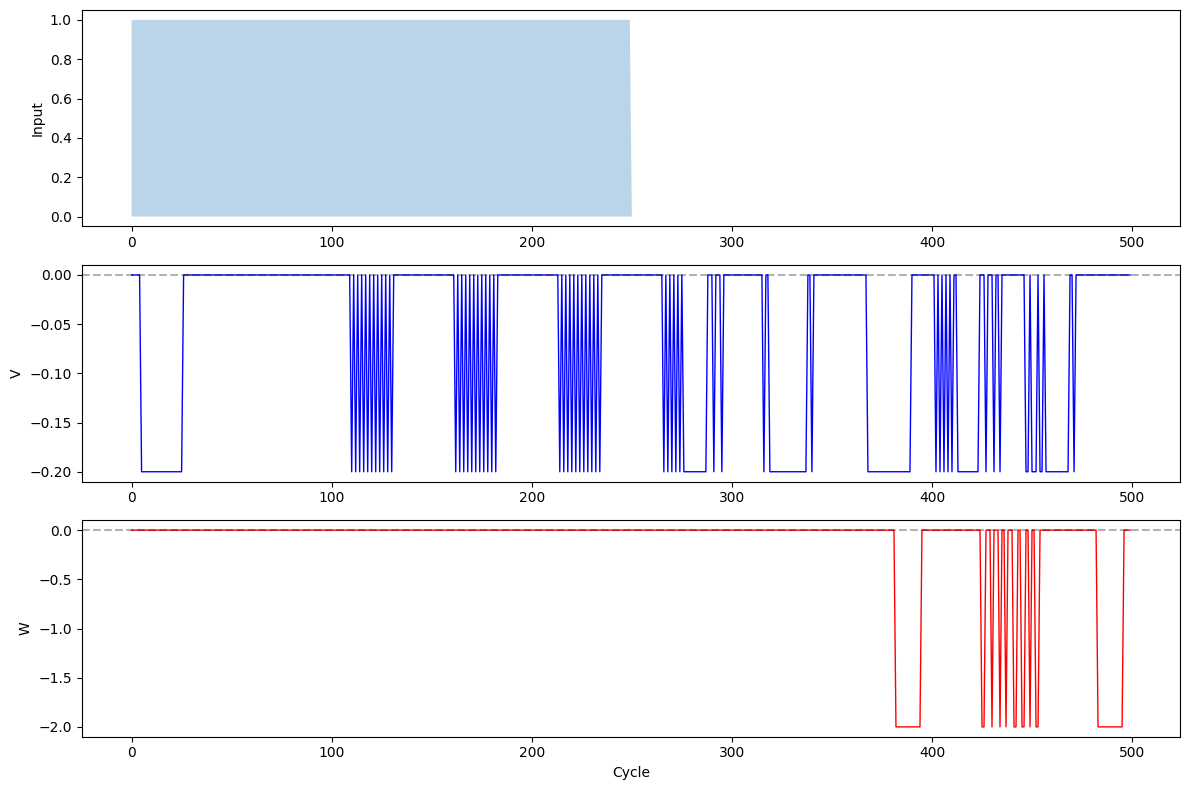

In [35]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))
ax1.fill_between(range(len(df)), df['input'].values, alpha=0.3)
ax1.set_ylabel('Input')

# Plot raw V
ax2.plot(df['v'].values, color='blue', linewidth=1)
ax2.set_ylabel('V')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Plot raw W
ax3.plot(df['w'].values, color='red', linewidth=1)
ax3.set_ylabel('W')
ax3.set_xlabel('Cycle')
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()